# 📈 ChurnGuard — Prédiction du Churn Clients

**Objectif :** Prédire quels clients vont résilier leur abonnement (churn) afin de cibler les actions de rétention.

**Dataset :** IBM Telco Customer Churn (7043 clients, 20 features)

**Pipeline complet :**
1. Exploration et compréhension des données (EDA)
2. Nettoyage et preprocessing
3. Feature engineering
4. Modélisation (LightGBM + optimisation du seuil)
5. Explicabilité SHAP
6. Simulation d'un dashboard décisionnel

---
**Auteure :** Saoussan Elhaouzi | **Stack :** Python · LightGBM · SHAP · Scikit-learn · Plotly


## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
import lightgbm as lgb

# Rééquilibrage
from imblearn.over_sampling import SMOTE

# Explicabilité
import shap

# Visualisation
import plotly.express as px
import plotly.graph_objects as go

# Configuration
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42

print("✅ Imports OK")

✅ Imports OK


## 1. Chargement des données

In [2]:
# Chargement du dataset Telco Customer Churn
df = pd.read_csv('telco_churn.csv')

print(f"📊 Dimensions : {df.shape}")
print(f"\n🎯 Variable cible - Churn :\n{df['Churn'].value_counts()}")
print(f"\n📈 Taux de churn : {(df['Churn'] == 'Yes').mean():.1%}")
df.head()

📊 Dimensions : (7043, 21)

🎯 Variable cible - Churn :
Churn
No     5174
Yes    1869
Name: count, dtype: int64

📈 Taux de churn : 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


## 2. Exploration des données (EDA)

In [3]:
# Vue d'ensemble
print("=== TYPES ET VALEURS MANQUANTES ===")
print(df.dtypes.to_string())
print(f"\nValeurs manquantes :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# Statistiques descriptives
print("\n=== STATISTIQUES NUMÉRIQUES ===")
df.describe()

=== TYPES ET VALEURS MANQUANTES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object

Valeurs manquantes :
Series([], dtype: int64)

=== STATISTIQUES NUMÉRIQUES ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762
std,0.369,24.559,30.090
min,0.000,0.000,18.250
25%,0.000,9.000,35.500
50%,0.000,29.000,70.350
75%,0.000,55.000,89.850
max,1.000,72.000,118.750


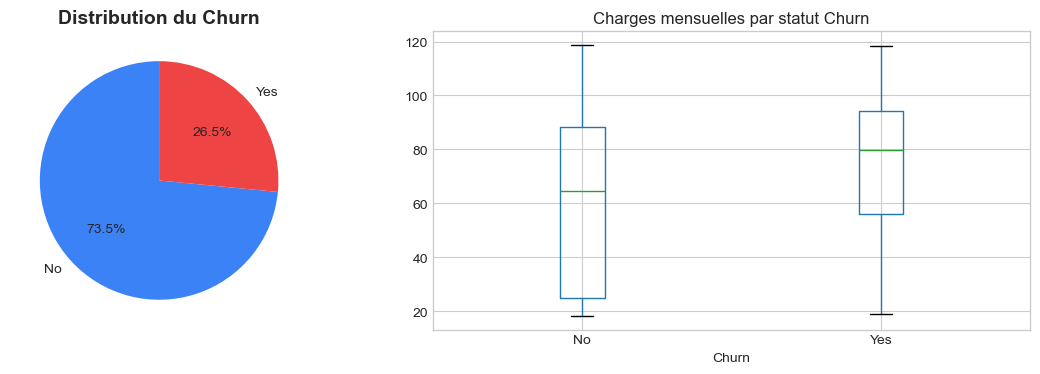

💡 Taux de churn moyen : 26.5%
💡 Charges moyennes Churned : 74.44€
💡 Charges moyennes Retained : 61.27€


In [4]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#3b82f6', '#ef4444'], startangle=90)
axes[0].set_title('Distribution du Churn', fontsize=14, fontweight='bold')

# Distribution des charges mensuelles par churn
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Charges mensuelles par statut Churn')
axes[1].set_xlabel('Churn')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"💡 Taux de churn moyen : {(df['Churn']=='Yes').mean():.1%}")
print(f"💡 Charges moyennes Churned : {df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}€")
print(f"💡 Charges moyennes Retained : {df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}€")

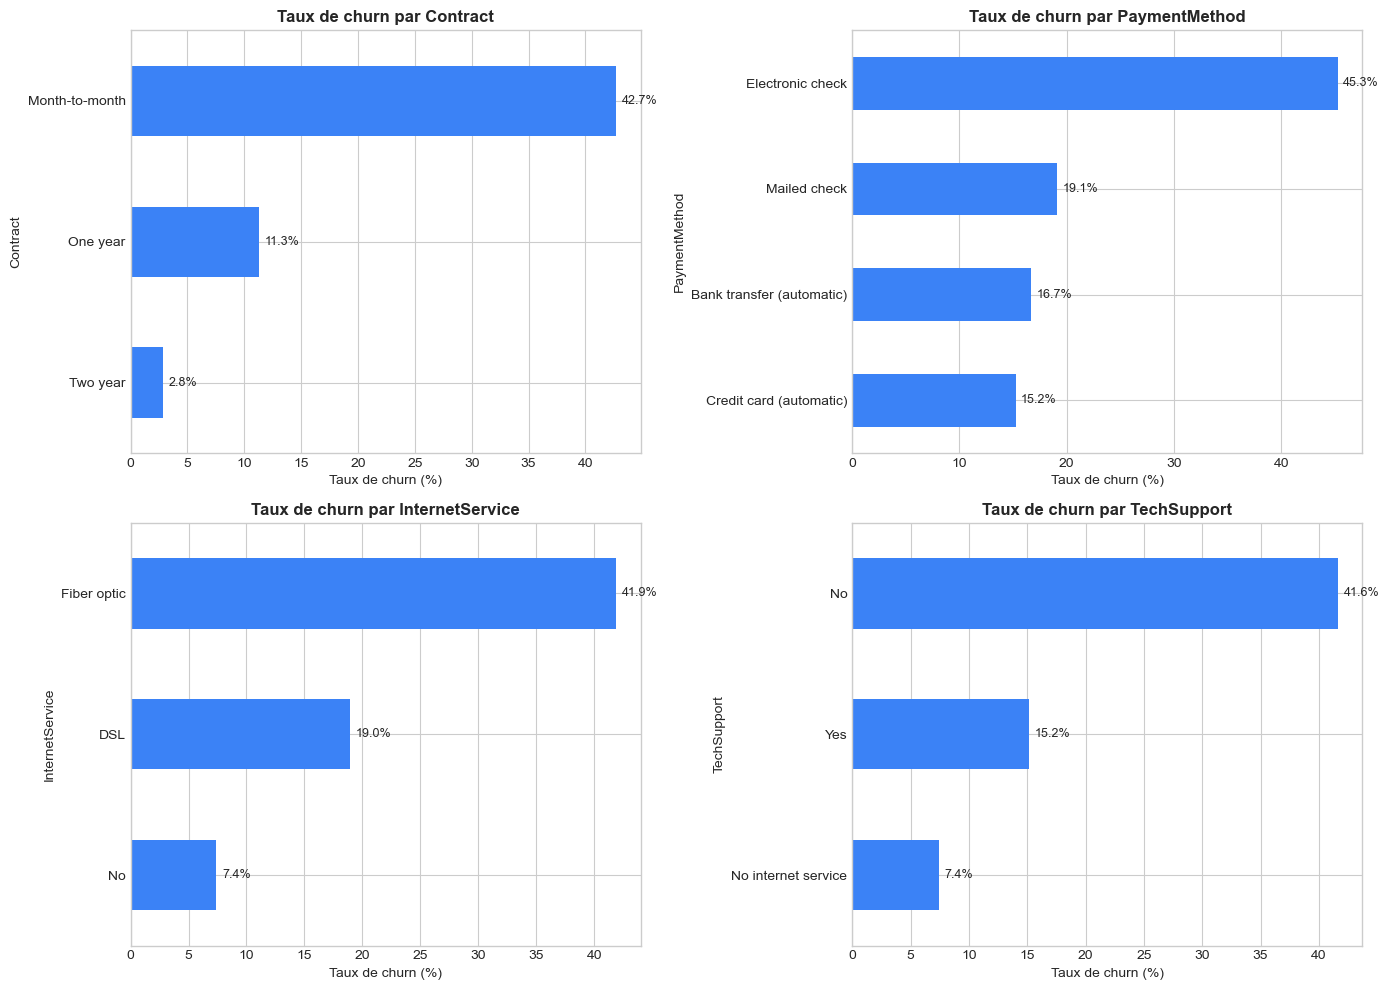

In [5]:
# Analyse des variables catégorielles les plus importantes
cat_features = ['Contract', 'PaymentMethod', 'InternetService', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feature in zip(axes.flatten(), cat_features):
    churn_rate = df.groupby(feature)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    churn_rate.sort_values(ascending=True).plot(kind='barh', ax=ax, color='#3b82f6')
    ax.set_title(f'Taux de churn par {feature}', fontweight='bold')
    ax.set_xlabel('Taux de churn (%)')
    for i, v in enumerate(churn_rate.sort_values(ascending=True)):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

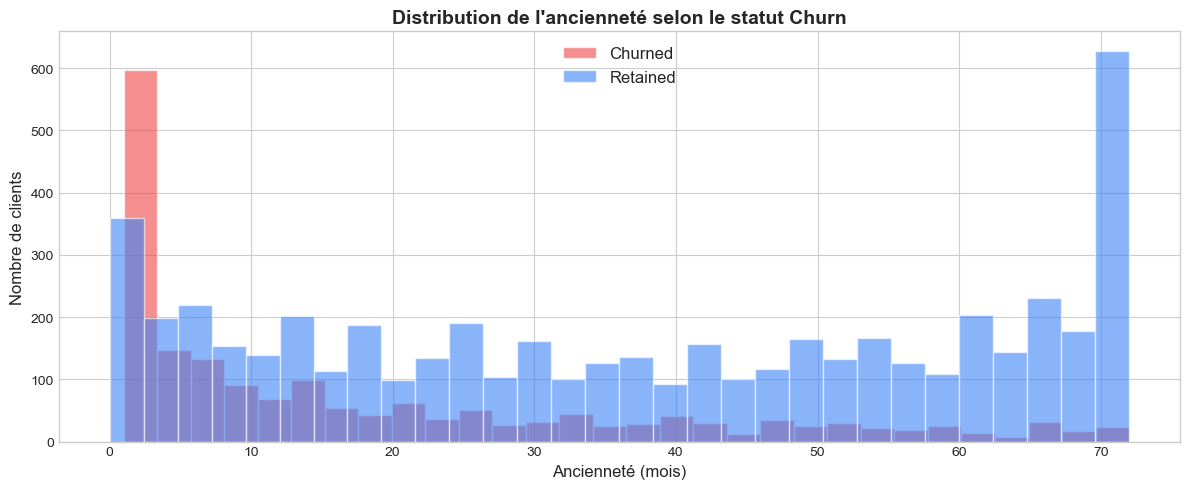

📊 Ancienneté moyenne Churned : 18.0 mois
📊 Ancienneté moyenne Retained : 37.6 mois


In [6]:
# Tenure (ancienneté) vs Churn
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
fig, ax = plt.subplots(figsize=(12, 5))
for churn_val, color, label in [('Yes', '#ef4444', 'Churned'), ('No', '#3b82f6', 'Retained')]:
    subset = df[df['Churn'] == churn_val]['tenure']
    ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

ax.set_xlabel("Ancienneté (mois)", fontsize=12)
ax.set_ylabel("Nombre de clients", fontsize=12)
ax.set_title("Distribution de l'ancienneté selon le statut Churn", fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"📊 Ancienneté moyenne Churned : {df[df['Churn']=='Yes']['tenure'].mean():.1f} mois")
print(f"📊 Ancienneté moyenne Retained : {df[df['Churn']=='No']['tenure'].mean():.1f} mois")

## 3. Nettoyage et preprocessing

In [7]:
# Copie de travail
df_clean = df.copy()

# 1. TotalCharges : convertir en numérique (contient des espaces)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
print(f"NaN dans TotalCharges après conversion : {df_clean['TotalCharges'].isna().sum()}")

# Les NaN correspondent aux clients avec tenure=0 → imputer par 0
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 2. Encoder la target
df_clean['Churn_binary'] = (df_clean['Churn'] == 'Yes').astype(int)

# 3. Supprimer les colonnes inutiles
df_clean = df_clean.drop(columns=['customerID', 'Churn'])

print(f"\n✅ Dataset nettoyé : {df_clean.shape}")
print(f"Taux de churn : {df_clean['Churn_binary'].mean():.1%}")
df_clean.head()

NaN dans TotalCharges après conversion : 11

✅ Dataset nettoyé : (7043, 20)
Taux de churn : 26.5%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1


In [8]:
# Encodage des variables catégorielles
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Variables catégorielles à encoder : {cat_cols}")

# Label Encoding (binaire ou ordinal)
le = LabelEncoder()
for col in cat_cols:
    if df_clean[col].nunique() == 2:
        df_clean[col] = le.fit_transform(df_clean[col])
        print(f"  ✅ {col} → Label Encoding ({df_clean[col].unique()})")
    else:
        dummies = pd.get_dummies(df_clean[col], prefix=col, drop_first=True)
        df_clean = pd.concat([df_clean.drop(columns=[col]), dummies], axis=1)
        print(f"  ✅ {col} → One-Hot Encoding ({dummies.shape[1]} nouvelles colonnes)")

print(f"\n📊 Dimensions après encodage : {df_clean.shape}")

Variables catégorielles à encoder : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
  ✅ gender → Label Encoding ([0 1])
  ✅ Partner → Label Encoding ([1 0])
  ✅ Dependents → Label Encoding ([0 1])
  ✅ PhoneService → Label Encoding ([0 1])
  ✅ MultipleLines → One-Hot Encoding (2 nouvelles colonnes)
  ✅ InternetService → One-Hot Encoding (2 nouvelles colonnes)
  ✅ OnlineSecurity → One-Hot Encoding (2 nouvelles colonnes)
  ✅ OnlineBackup → One-Hot Encoding (2 nouvelles colonnes)
  ✅ DeviceProtection → One-Hot Encoding (2 nouvelles colonnes)
  ✅ TechSupport → One-Hot Encoding (2 nouvelles colonnes)
  ✅ StreamingTV → One-Hot Encoding (2 nouvelles colonnes)
  ✅ StreamingMovies → One-Hot Encoding (2 nouvelles colonnes)
  ✅ Contract → One-Hot Encoding (2 nouvelles colonnes)
  ✅ PaperlessBilling → Label En

## 4. Feature Engineering

In [ ]:
# Créer de nouvelles features pertinentes
df_feat = df_clean.copy()

# Ratio charges / ancienneté (charge moyenne par mois)
df_feat['charges_per_tenure'] = np.where(
    df_feat['tenure'] > 0,
    df_feat['TotalCharges'] / df_feat['tenure'],
    df_feat['MonthlyCharges']
)

# Nombre de services souscrits
service_cols = [c for c in df_feat.columns if any(s in c for s in
               ['PhoneService', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies'])]
df_feat['nb_services'] = df_feat[[c for c in service_cols if c in df_feat.columns]].sum(axis=1)

# Client à risque : charges élevées + faible ancienneté
df_feat['risque_financier'] = ((df_feat['MonthlyCharges'] > df_feat['MonthlyCharges'].quantile(0.75)) &
                                (df_feat['tenure'] < 12)).astype(int)

print("✅ Features créées :")
print(f"  - charges_per_tenure : {df_feat['charges_per_tenure'].describe().round(2).to_dict()}")
print(f"  - nb_services (min/max) : {df_feat['nb_services'].min():.0f} / {df_feat['nb_services'].max():.0f}")
print(f"  - risque_financier : {df_feat['risque_financier'].mean():.1%} des clients")
print(f"\n📊 Dataset final : {df_feat.shape}")

## 5. Modélisation — LightGBM

In [ ]:
# Séparation features / target
X = df_feat.drop(columns=['Churn_binary'])
y = df_feat['Churn_binary']

print(f"Features : {X.shape[1]} colonnes")
print(f"Distribution cible : {y.value_counts().to_dict()}")
print(f"Taux de churn : {y.mean():.1%}")

# SPLIT — toujours AVANT le SMOTE !
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"\n✅ Split effectué :")
print(f"   Train : {X_train.shape[0]} exemples ({y_train.mean():.1%} churn)")
print(f"   Test  : {X_test.shape[0]} exemples ({y_test.mean():.1%} churn)")

In [ ]:
# SMOTE — uniquement sur le train !
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Avant SMOTE : {y_train.value_counts().to_dict()}")
print(f"Après SMOTE : {pd.Series(y_train_res).value_counts().to_dict()}")

In [ ]:
# Entraînement du modèle LightGBM
model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

print(f"✅ Modèle entraîné — {model.best_iteration_} estimateurs")

In [ ]:
# Évaluation sur le test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RAPPORT DE CLASSIFICATION")
print("=" * 50)
print(classification_report(y_test, y_pred))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
ax.set_title('Matrice de confusion — LightGBM', fontsize=14, fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.show()

## 6. Optimisation du seuil de décision

In [ ]:
# Le seuil par défaut est 0.5 — on peut l'optimiser selon le contexte métier
# Ici : on veut maximiser le rappel (ne pas manquer de churners)
# tout en gardant une précision acceptable

thresholds = np.arange(0.1, 0.9, 0.02)
results = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    results.append({
        'seuil': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'rappel': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })

df_thresholds = pd.DataFrame(results)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_thresholds['seuil'], df_thresholds['precision'], 'b-', label='Précision', linewidth=2)
ax.plot(df_thresholds['seuil'], df_thresholds['rappel'], 'r-', label='Rappel', linewidth=2)
ax.plot(df_thresholds['seuil'], df_thresholds['f1'], 'g--', label='F1-Score', linewidth=2)
ax.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')

# Seuil optimal F1
best_t = df_thresholds.loc[df_thresholds['f1'].idxmax(), 'seuil']
ax.axvline(best_t, color='green', linestyle='--', linewidth=2, label=f'Seuil optimal F1 ({best_t:.2f})')

ax.set_xlabel('Seuil de décision', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Précision / Rappel / F1 selon le seuil', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0.1, 0.9)
plt.tight_layout()
plt.show()

print(f"\n🎯 Seuil optimal (F1) : {best_t:.2f}")
print(f"   → Précision : {df_thresholds.loc[df_thresholds['f1'].idxmax(), 'precision']:.3f}")
print(f"   → Rappel    : {df_thresholds.loc[df_thresholds['f1'].idxmax(), 'rappel']:.3f}")
print(f"   → F1-Score  : {df_thresholds.loc[df_thresholds['f1'].idxmax(), 'f1']:.3f}")

## 7. Explicabilité SHAP

In [ ]:
# Calculer les valeurs SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Importance globale des features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X_test, plot_type='bar', max_display=15,
                  show=False)
plt.title('Importance des features — SHAP (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# SHAP summary plot (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1] if isinstance(shap_values, list) else shap_values,
                  X_test, max_display=15, show=False)
plt.title('Impact des features sur le churn — SHAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Explication d'une prédiction individuelle
# Exemple : client à fort risque de churn
idx_at_risk = np.argmax(y_prob)
print(f"Client le plus à risque (index {idx_at_risk})")
print(f"  Probabilité de churn : {y_prob[idx_at_risk]:.1%}")
print(f"  Réel : {'Churned' if y_test.iloc[idx_at_risk] == 1 else 'Retained'}")
print(f"\nProfil du client :")
print(X_test.iloc[idx_at_risk].to_frame().T.to_string())

## 8. Cross-validation et évaluation finale

In [ ]:
# Cross-validation 5-fold sur le dataset d'entraînement complet
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                        class_weight='balanced', random_state=RANDOM_STATE, verbose=-1),
    X_train, y_train,
    cv=cv, scoring='roc_auc'
)

print("=" * 50)
print("RÉSULTATS FINAUX")
print("=" * 50)
print(f"CV AUC-ROC (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Test AUC-ROC        : {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n📌 Le modèle identifie correctement {roc_auc_score(y_test, y_prob):.0%}")
print("   des cas de churn vs non-churn.")

## 9. Prochaines étapes — Pour aller plus loin

- [ ] **API FastAPI** : créer un endpoint `/predict` qui reçoit le profil d'un client et retourne sa probabilité de churn
- [ ] **Dashboard Streamlit** : visualiser les clients à risque, filtrer par segment, voir les explications SHAP individuelles
- [ ] **Dashboard Power BI** : connecter à une base de données simulée et construire un tableau de bord décisionnel
- [ ] **A/B test** : mesurer l'impact des actions de rétention sur le taux de churn réel

```python
# Structure FastAPI à implémenter
# POST /predict
# Input : profil client (JSON)
# Output : {"churn_probability": 0.73, "risk_level": "HIGH", "top_factors": [...]}
```
